In [3]:
from IPython.core.interactiveshell import InteractiveShell
from jedi.plugins.stdlib import collections_namedtuple
from pandas.conftest import ascending
from pandas.core.config_init import styler_formatter

InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Basic Data Analysis**

In [80]:
data = pd.read_csv("netflix_titles.csv")
data.head()
data.info()
data.describe()
data.isnull().sum()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
data.type.value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [6]:
data.country.value_counts(15)

country
United States                                    0.353310
India                                            0.121866
United Kingdom                                   0.052533
Japan                                            0.030717
South Korea                                      0.024950
                                                   ...   
Russia, Spain                                    0.000125
Croatia, Slovenia, Serbia, Montenegro            0.000125
Japan, Canada                                    0.000125
United States, France, South Korea, Indonesia    0.000125
United Arab Emirates, Jordan                     0.000125
Name: proportion, Length: 748, dtype: float64

## **Value counts of Movies and TV Shows**

<Axes: xlabel='type', ylabel='count'>

Text(0.5, 0, 'TYPE')

Text(0, 0.5, 'COUNTRY')

/var/folders/m_/1nm0glmx6l7_34kr6qd4zyfw0000gn/T/ipykernel_808/1825530666.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


Text(0.5, 1.0, 'Type Count Distribution')

/var/folders/m_/1nm0glmx6l7_34kr6qd4zyfw0000gn/T/ipykernel_808/1825530666.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


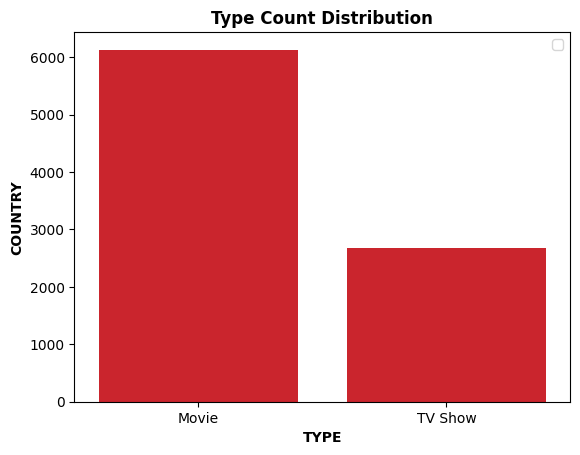

In [59]:
sns.countplot(data=data,x='type',color='#E50914')
plt.xlabel('TYPE',fontweight='bold')
plt.ylabel('COUNTRY',fontweight='bold')
plt.legend(loc='upper left')
plt.title("Type Count Distribution",fontweight='bold')
plt.legend(loc='upper right')
plt.show()

In [8]:
data.fillna({
    'director':'Unknown',
    'cast':'Unknown',
    "country":"Unknown"
})

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [11]:
data['date_added']=data['date_added'].str.strip()
data['data_added']=pd.to_datetime(data['date_added'],errors='coerce')
data['date_added']=pd.to_datetime(data['date_added']).dt.year

## **Content added per Year**

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='date_added', ylabel='count'>

Text(0.5, 0, 'DATE ADDED')

Text(0, 0.5, 'COUNT')

Text(0.5, 1.0, 'COUNT Distribution')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2008.0'),
  Text(1, 0, '2009.0'),
  Text(2, 0, '2010.0'),
  Text(3, 0, '2011.0'),
  Text(4, 0, '2012.0'),
  Text(5, 0, '2013.0'),
  Text(6, 0, '2014.0'),
  Text(7, 0, '2015.0'),
  Text(8, 0, '2016.0'),
  Text(9, 0, '2017.0'),
  Text(10, 0, '2018.0'),
  Text(11, 0, '2019.0'),
  Text(12, 0, '2020.0'),
  Text(13, 0, '2021.0')])

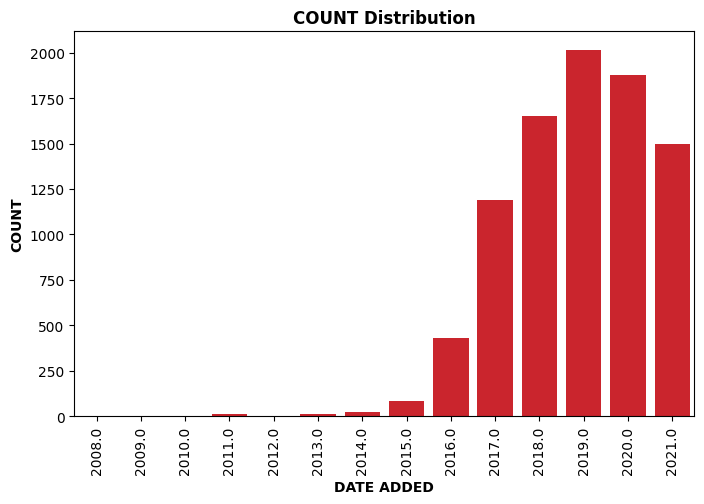

In [58]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x='date_added',color='#E50914')
plt.xlabel('DATE ADDED',fontweight='bold')
plt.ylabel('COUNT',fontweight='bold')
plt.title('COUNT Distribution',fontweight='bold')
plt.xticks(rotation=90)
plt.show()

<Figure size 1000x500 with 0 Axes>

Text(0.5, 0, 'Count')

Text(0, 0.5, 'Rating')

Text(0.5, 1.0, 'Rating Distribution')

[Text(0, 0, '3207'),
 Text(0, 0, '2160'),
 Text(0, 0, '863'),
 Text(0, 0, '799'),
 Text(0, 0, '490'),
 Text(0, 0, '334'),
 Text(0, 0, '307'),
 Text(0, 0, '287'),
 Text(0, 0, '220'),
 Text(0, 0, '80'),
 Text(0, 0, '41'),
 Text(0, 0, '6'),
 Text(0, 0, '3'),
 Text(0, 0, '3'),
 Text(0, 0, '1'),
 Text(0, 0, '1'),
 Text(0, 0, '1')]

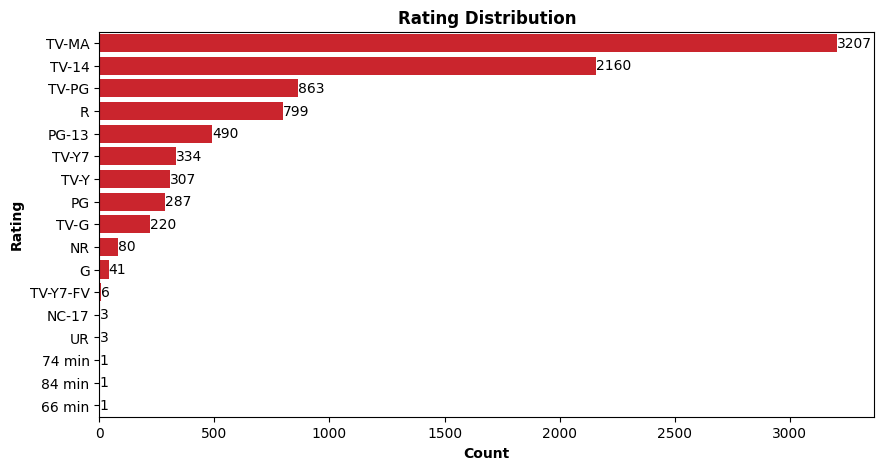

In [57]:
plt.figure(figsize=(10,5))
ax =sns.countplot(data=data,y='rating',order=data['rating'].value_counts().index,color='#E50914')
plt.xlabel('Count',fontweight='bold')
plt.ylabel('Rating',fontweight='bold')
plt.title('Rating Distribution',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## **Top Countries Distribution**



We separated the unknown from the data to visualise which of the countries have highest releases

In [61]:
import collections
from collections import Counter

In [62]:
genres = data['listed_in'].str.split(' , ').sum()
top_genres = Counter(genres).most_common(10)

top_genres

[('Dramas, International Movies', 362),
 ('Documentaries', 359),
 ('Stand-Up Comedy', 334),
 ('Comedies, Dramas, International Movies', 274),
 ('Dramas, Independent Movies, International Movies', 252),
 ("Kids' TV", 220),
 ('Children & Family Movies', 215),
 ('Children & Family Movies, Comedies', 201),
 ('Documentaries, International Movies', 186),
 ('Dramas, International Movies, Romantic Movies', 180)]

In [84]:
data_country = data[data['country'] != "Unknown"]
data_country['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='country'>

Text(0.5, 0, 'Countries')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'Countries Distribution')

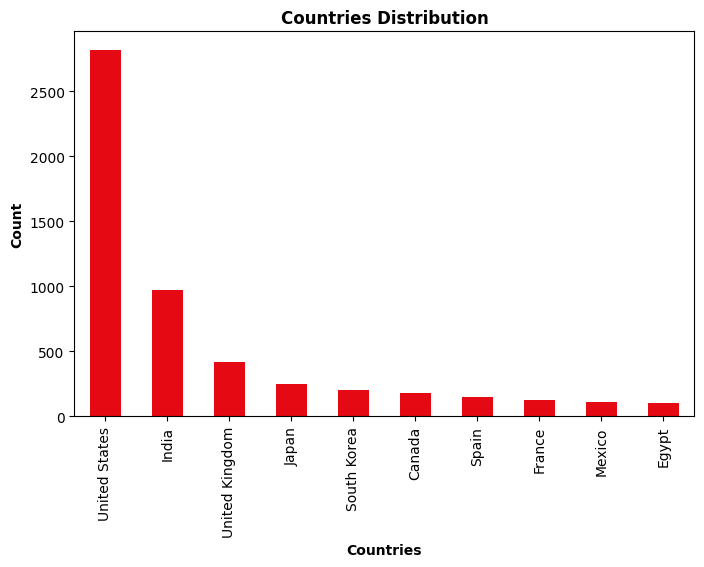

In [85]:
top_countries = data['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
top_countries.plot(kind='bar',color='#E50914')
plt.xlabel('Countries',fontweight='bold')
plt.ylabel('Count',fontweight='bold')
plt.title('Countries Distribution',fontweight='bold')
plt.show()

## **Content Added to Netflix per year**

In [76]:
from IPython.core.interactiveshell import InteractiveShell


InteractiveShell.ast_node_interactivity = "all"

In [89]:
data['date_added'] = pd.to_datetime(data['date_added'],errors='coerce')
data['year_added'] = data['date_added'].dt.year

year_added_count = data['year_added'].value_counts().sort_index()



<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='year_added'>

Text(0.5, 0, 'Year Added')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'Year Added Distribution')

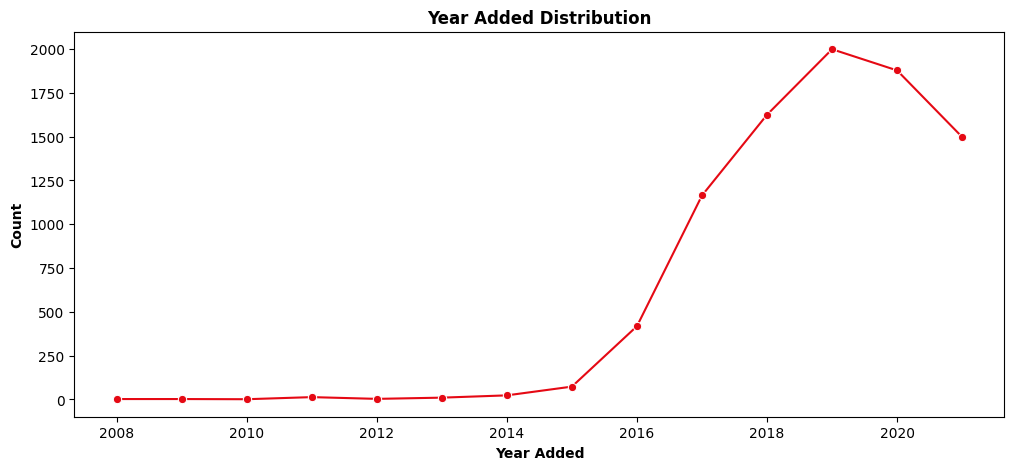

In [98]:
plt.figure(figsize=(12,5))
sns.lineplot(x=year_added_count.index,y=year_added_count.values,color='#E50914',marker='o')
plt.xlabel('Year Added',fontweight='bold')
plt.ylabel('Count',fontweight='bold')
plt.title('Year Added Distribution',fontweight='bold')
plt.show()

## **Movie and TV Shows distribution**

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='year_added', ylabel='count'>

Text(0.5, 0, 'Year Added')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'Type Distribution')

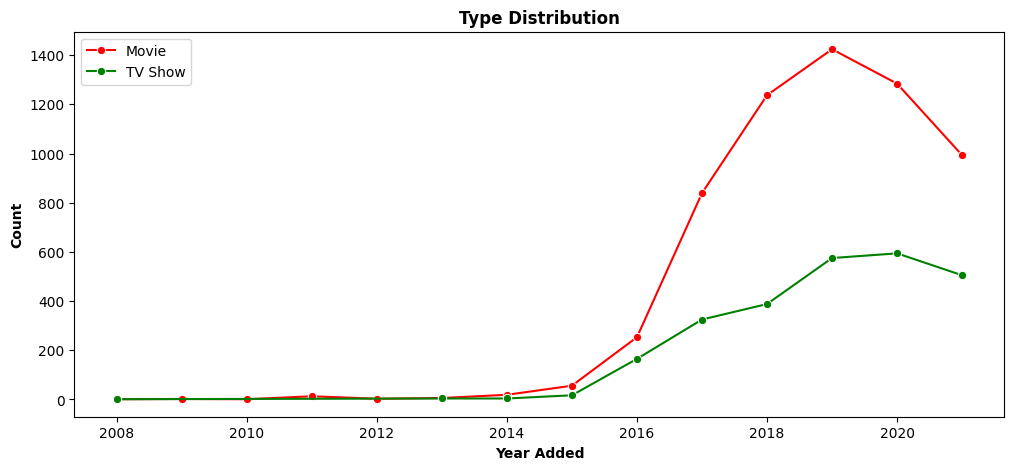

In [106]:
type_year = data.groupby(['year_added','type']).size().reset_index(name='count')

plt.figure(figsize=(12,5))
sns.lineplot(data=type_year,x='year_added',y='count',palette=['red','green'],hue='type',marker='o')
plt.xlabel('Year Added',fontweight='bold')
plt.ylabel('Count',fontweight='bold')
plt.title('Type Distribution',fontweight='bold')
plt.legend(loc='upper left')
plt.show()

## **TOP 10 Directors**

<Figure size 1200x500 with 0 Axes>

<Axes: ylabel='director'>

Text(0, 0.5, 'Director')

Text(0.5, 0, 'Count')

Text(0.5, 1.0, 'Top 10 Directors')

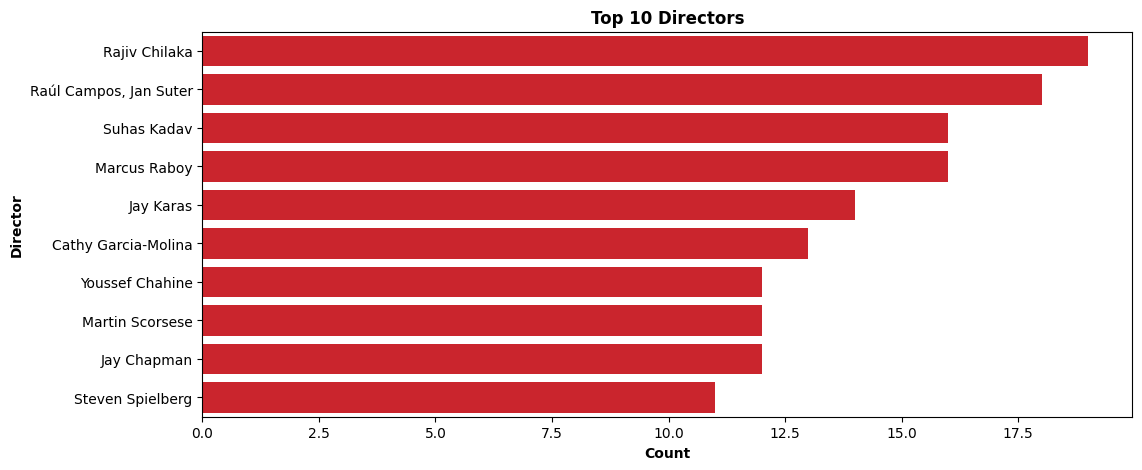

In [111]:
data['director'] =data['director'].fillna('Unknown')
top_directors = data[data['director'] != "Unknown"]['director'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_directors.values,y=top_directors.index,color='#E50914')
plt.ylabel('Director',fontweight='bold')
plt.xlabel('Count',fontweight='bold')
plt.title('Top 10 Directors',fontweight='bold')
plt.show()

## **TOP 5 Genres Distribution**

listed_in_splits
 International Movies    2624
Dramas                   1600
Comedies                 1210
Action & Adventure        859
Documentaries             829
Name: count, dtype: int64

<Figure size 600x600 with 0 Axes>

([<matplotlib.patches.Wedge at 0x12e729950>,
 [Text(0.4418181450708801, 1.007371196077259, ' International Movies'),
  Text(-1.0919752770454791, 0.13262727593315557, 'Dramas'),
  Text(-0.4805790715241773, -0.9894663996381887, 'Comedies'),
  Text(0.4888556689766503, -0.9854035391195791, 'Action & Adventure'),
  Text(1.0272686972291032, -0.3933433915718187, 'Documentaries')],
 [Text(0.24099171549320728, 0.549475197860323, '36.8%'),
  Text(-0.5956228783884431, 0.07234215050899394, '22.5%'),
  Text(-0.26213403901318755, -0.5397089452571938, '17.0%'),
  Text(0.26664854671453647, -0.5374928395197703, '12.1%'),
  Text(0.5603283803067836, -0.21455094085735563, '11.6%')])

Text(0.5, 1.0, 'Top 5 Genres')

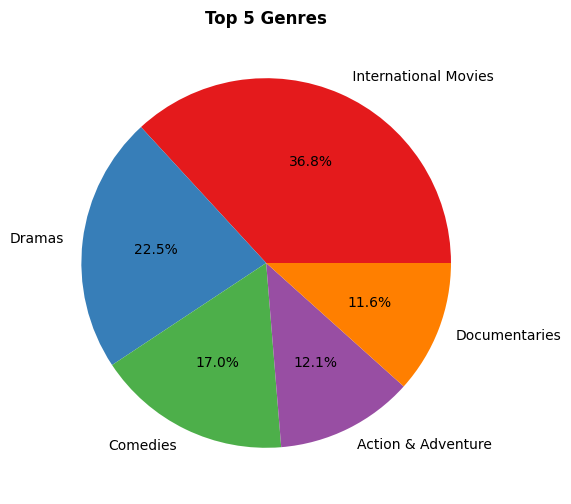

Text(0.5, 1.0, 'Top 5 Genres')

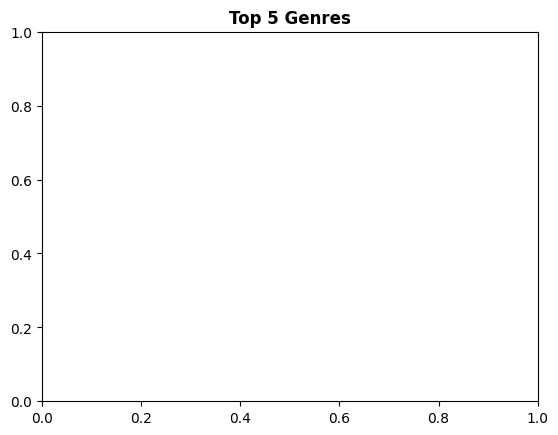

In [142]:
data['listed_in_splits'] = data['listed_in'].str.split(',')
genre_list = data.explode('listed_in_splits')

top_5_genres = genre_list['listed_in_splits'].value_counts().head(5)
top_5_genres

plt.figure(figsize=(6,6))
plt.pie(top_5_genres.values,labels=top_5_genres.index,autopct='%1.1f%%',colors=plt.cm.Set1.colors)
plt.title('Top 5 Genres',fontweight='bold')
plt.show()
plt.title('Top 5 Genres',fontweight='bold')
plt.show()